In [59]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import sunpy.visualization.colormaps as sunpycm
from sunpy.visualization.colormaps import color_tables
from loguru import logger as lgr_logger
from omegaconf import OmegaConf
from matplotlib.colors import TwoSlopeNorm

from sdofmv2.core import MAE, SDOMLDataModule, inverse_log_norm
from sdofmv2.utils import ALL_WAVELENGTHS, ALL_COMPONENTS

In [60]:
cfg = OmegaConf.load(
    "../../../configs/pretrain/pretrain_mae_ALL.yaml"
    )

In [61]:
def get_file_name(file_path: str):
    file = Path(file_path)
    return file.name

In [62]:
cache_dir = "../../../assets/cache/ALL/"
train_index = get_file_name(cfg.data.train_index)
val_index = get_file_name(cfg.data.val_index)
test_index = get_file_name(cfg.data.test_index)

data_module = SDOMLDataModule(
    hmi_path=os.path.join(
        cfg.data.sdoml.base_directory, 
        cfg.data.sdoml.sub_directory.hmi
    ) if cfg.data.sdoml.sub_directory.hmi else None,
    aia_path=os.path.join(
        cfg.data.sdoml.base_directory,
        cfg.data.sdoml.sub_directory.aia,
    ) if cfg.data.sdoml.sub_directory.aia else None,
    eve_path=None,
    components=cfg.data.sdoml.components,
    wavelengths=cfg.data.sdoml.wavelengths,
    ions=cfg.data.sdoml.ions,
    batch_size=cfg.model.misc.batch_size,
    num_workers=cfg.data.num_workers,
    train_index=cache_dir + train_index,
    val_index=cache_dir + val_index,
    test_index=cache_dir + test_index,
    num_frames=cfg.model.mae.num_frames,
    drop_frame_dim=cfg.data.drop_frame_dim,
    apply_mask=cfg.data.sdoml.apply_mask,
    precision=cfg.experiment.precision,
    normalization=cfg.data.sdoml.normalization,
    normalization_stat_path=cache_dir,
)
data_module.setup()

2026-06-07 02:43:49.688 | INFO     | sdofmv2.core.datamodule:setup:636 - Train dataloader is ready!
2026-06-07 02:43:49.688 | INFO     | sdofmv2.core.datamodule:setup:637 - Dataset size: 223044
2026-06-07 02:43:49.709 | INFO     | sdofmv2.core.datamodule:setup:655 - Validation dataloader is ready!
2026-06-07 02:43:49.710 | INFO     | sdofmv2.core.datamodule:setup:656 - Dataset size: 23123
2026-06-07 02:43:49.730 | INFO     | sdofmv2.core.datamodule:setup:674 - test dataloader is ready!
2026-06-07 02:43:49.731 | INFO     | sdofmv2.core.datamodule:setup:675 - Dataset size: 24618


In [63]:
aia_list = (
    ALL_WAVELENGTHS
    if cfg.data.sdoml.sub_directory.aia and cfg.data.sdoml.wavelengths is None
    else cfg.data.sdoml.wavelengths or []
)

hmi_list = (
    ALL_COMPONENTS
    if cfg.data.sdoml.sub_directory.hmi and cfg.data.sdoml.components is None
    else cfg.data.sdoml.components or []
)

aia_list.sort()
hmi_list.sort()
chan_types = aia_list + hmi_list

cms = [
    sunpycm.cmlist.get("sdoaia131"),
    sunpycm.cmlist.get("sdoaia1600"),
    sunpycm.cmlist.get("sdoaia1700"),
    sunpycm.cmlist.get("sdoaia171"),
    sunpycm.cmlist.get("sdoaia193"),
    sunpycm.cmlist.get("sdoaia211"),
    sunpycm.cmlist.get("sdoaia304"),
    sunpycm.cmlist.get("sdoaia335"),
    sunpycm.cmlist.get("sdoaia94"),
    color_tables.hmi_mag_color_table(),
    color_tables.hmi_mag_color_table(),
    color_tables.hmi_mag_color_table(),
]

In [64]:
ckpt_dir = "../../../assets/checkpoints/backbone/"
model = MAE.load_from_checkpoint(
    checkpoint_path=ckpt_dir+"ALL/id_qu7tsc5c_mae_epoch=67-val_loss=0.08.ckpt", 
    map_location="cpu",
    weights_only=False,
    masking_ratio=0.5)
lgr_logger.info(f"masking ratio of sdofmv2: {model.masking_ratio}")

model_no_mask = MAE.load_from_checkpoint(
    checkpoint_path= ckpt_dir + "ALL/id_qu7tsc5c_mae_epoch=67-val_loss=0.08.ckpt", 
    map_location="cpu",
    weights_only=False,
    masking_ratio=0)
lgr_logger.info(f"masking ratio of sdofmv2: {model_no_mask.masking_ratio}")


2026-06-07 02:43:53.858 | INFO     | __main__:<module>:7 - masking ratio of sdofmv2: 0.5
2026-06-07 02:43:55.098 | INFO     | __main__:<module>:14 - masking ratio of sdofmv2: 0


In [65]:
timestamps = ["2011-12-25 00:12:00"]

img_indices = [
    data_module.test_ds.aligndata.index.get_loc(
        pd.to_datetime(i_time)
    ) for i_time in timestamps
]

x_set = torch.cat([data_module.test_ds[i][0].unsqueeze(0) for i in img_indices], dim=0)
ts = [pd.to_datetime(data_module.test_ds[i][1]) for i in img_indices]

In [66]:
model.eval()

with torch.no_grad():
    output = model(x_set)
    output_wo_mask = model_no_mask(x_set)


In [68]:
x_set.shape

torch.Size([1, 12, 1, 512, 512])

In [70]:
x_set_denorm = x_set.clone()
output_denorm = output[0].clone()
output_wo_mask_denorm = output_wo_mask[0].clone()

# inverse transformation of hmi
for i_img in range(x_set.shape[0]):
    for ch_id, ch in enumerate(chan_types[-3:]):

        x_set_denorm[i_img, ch_id+9, 0, :, :] = inverse_log_norm(
            x_set[i_img, ch_id+9, 0, :, :],
            data_module.normalization_stat,
            ch,
            cfg.data.sdoml.normalization.scaler_factor,
        )

        output_denorm[i_img, ch_id+9, 0, :, :] = inverse_log_norm(
            output[0][i_img, ch_id+9, 0, :, :],
            data_module.normalization_stat,
            ch,
            cfg.data.sdoml.normalization.scaler_factor,
        )

        output_wo_mask_denorm[i_img, ch_id+9, 0, :, :] = inverse_log_norm(
            output_wo_mask[0][i_img, ch_id+9, 0, :, :],
            data_module.normalization_stat,
            ch,
            cfg.data.sdoml.normalization.scaler_factor,
        )

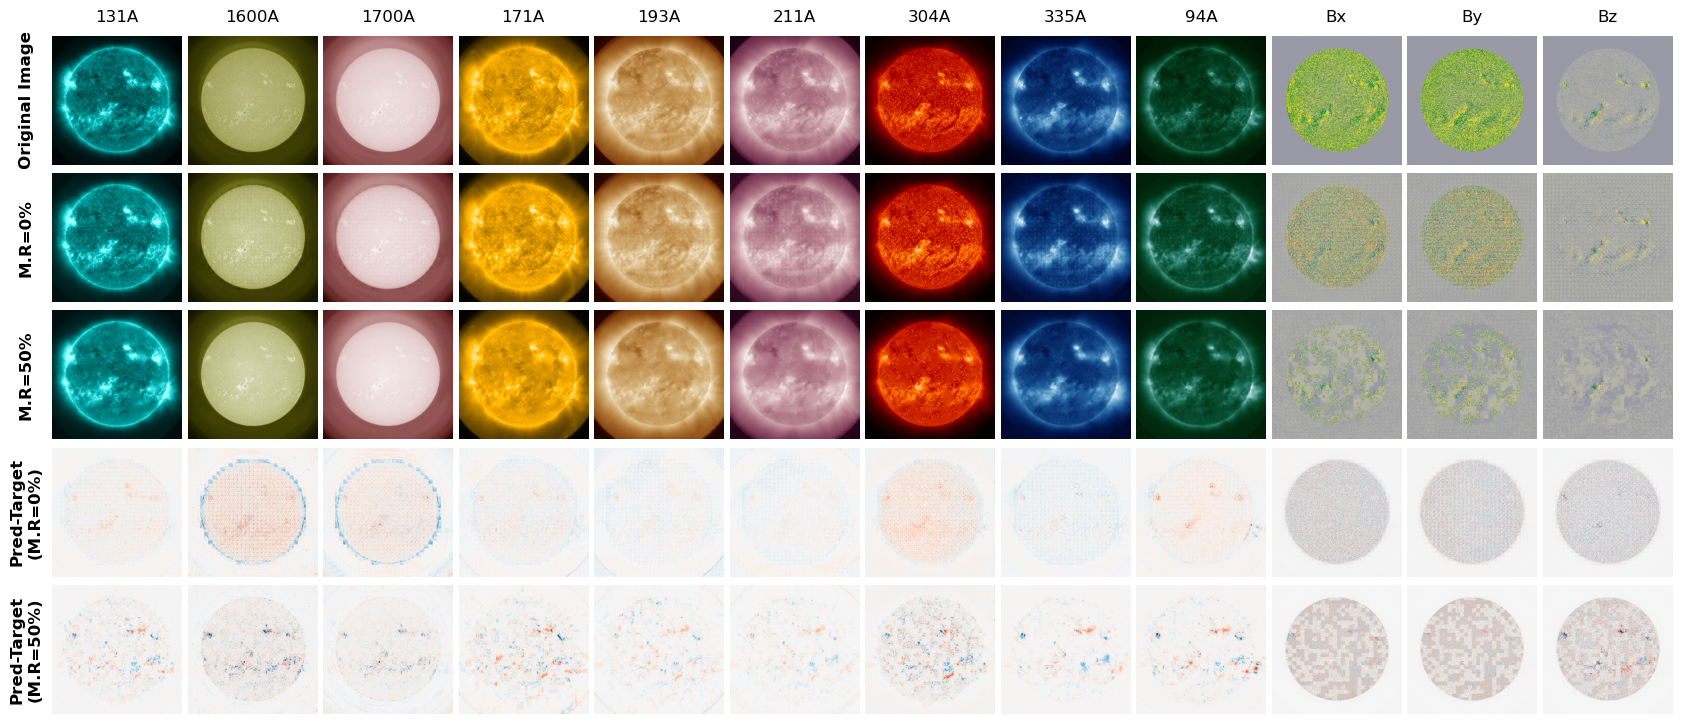

In [74]:
# normalization for visualization
norm = TwoSlopeNorm(vmin=-4000, vcenter=0, vmax=4000)

# error norm for AIA
err_wo_mask_aia = output_wo_mask[0][0, :9, 0, :, :] - x_set[0, :9, 0, :, :]
err_mp_mask_aia = output[0][0, :9, 0, :, :] - x_set[0, :9, 0, :, :]
lim_aia = np.quantile(np.abs(np.stack([err_wo_mask_aia, err_mp_mask_aia], axis=0)), 0.9999)
# lim_aia = np.max(np.abs(np.stack([err_wo_mask_aia, err_mp_mask_aia], axis=0)))
norm_aia = TwoSlopeNorm(vmin=-lim_aia, vcenter=0, vmax=lim_aia)

# error norm for HMI
err_wo_mask_hmi = output_wo_mask[0][0, 9:, 0, :, :] - x_set[0, 9:, 0, :, :]
err_mp_mask_hmi = output[0][0, 9:, 0, :, :] - x_set[0, 9:, 0, :, :]
lim_hmi = np.quantile(np.abs(np.stack([err_wo_mask_hmi, err_mp_mask_hmi], axis=0)), 0.9999)
# lim_hmi = np.max(np.abs(np.stack([err_wo_mask_hmi, err_mp_mask_hmi], axis=0)))
norm_hmi = TwoSlopeNorm(vmin=-lim_hmi, vcenter=0, vmax=lim_hmi)

# plot figure
fig, axes = plt.subplots(nrows=5, ncols=12, figsize=(18, 8))

for ax in axes.flat:
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

for i, col in enumerate(chan_types):
    # --- Row 0: Original Image ---
    axes[0][i].imshow(x_set_denorm[0, i, 0, :, :], cmap=cms[i], norm=norm if i>=9 else None)
    axes[0][i].set_title(f"{col}", fontsize=12, pad=10)
    
    # --- Row 1: 0% Masking (Reconstruction) ---
    axes[1][i].imshow(output_wo_mask_denorm[0, i, 0, :, :], cmap=cms[i], norm=norm if i>=9 else None)
    
    # --- Row 2: 50% Masking (Inpainting/Prediction) ---
    axes[2][i].imshow(output_denorm[0, i, 0, :, :], cmap=cms[i], norm=norm if i>=9 else None)

    # visualize errors
    axes[3][i].imshow(output_wo_mask[0][0, i, 0, :, :] - x_set[0, i, 0, :, :], cmap='RdBu_r', norm=norm_aia if i<=9 else norm_hmi)
    axes[4][i].imshow(output[0][0, i, 0, :, :] - x_set[0, i, 0, :, :], cmap='RdBu_r', norm=norm_aia if i<=9 else norm_hmi)


row_info = [
    "Original Image", 
    "M.R=0%", # "Masking Ratio: \n 0%",   # Or "M.R. = 0.0"
    "M.R=50%", # "Masking Ratio: \n 50%"   # Or "M.R. = 0.5"
    "Pred-Target\n(M.R=0%)",
    "Pred-Target\n(M.R=50%)",
]

for row_idx in range(5):
    axes[row_idx][0].text(
        -0.2, 0.5,
        f"{row_info[row_idx]}", 
        ha='center', 
        va='center', 
        fontsize=12, 
        fontweight='bold', # Added bold for better readability
        rotation=90,
        transform=axes[row_idx][0].transAxes 
    )

plt.subplots_adjust(wspace=0.05, hspace=0.05, left=0.05, right=0.95, top=0.9, bottom=0.05)

plt.savefig(f"SDOFMv2_withALL_results_mask_ratio.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [45]:
np.nanmean(output_wo_mask[0][0, 9, 0, :, :] - x_set[0, 9, 0, :, :])

np.float32(-182.4166)

In [34]:
np.quantile(np.abs(np.stack([err_wo_mask_aia, err_mp_mask_aia], axis=0)), 0.99999)

np.float32(5.1938877)

In [31]:
np.max(np.abs(np.stack([err_wo_mask_aia, err_mp_mask_aia], axis=0)))

np.float32(10.826504)